In [ ]:
import sys
import os
# Add the scripts folder to the path
sys.path.append(os.path.abspath("scripts"))

# Import functions
from data_processing import convert_all_nc4_to_csv, load_combined_dataframe, get_season
from spatial_analysis import (filter_by_africa_bounds, get_africa_shape, 
                              create_geodataframe_from_grid, clip_to_africa,
                              create_geodataframe_polygons, extract_land_cover)
from visualization import (plot_monthly_grid, plot_annual_mean_map, 
                           plot_seasonal_maps, plot_monthly_timeseries, 
                           plot_co2_by_land_cover)

In [2]:
# 1. Processing
convert_all_nc4_to_csv("data", "data_csv")

Processed 362 files.


In [9]:
df_all = load_combined_dataframe("data_csv")

In [10]:
# 2. DATA LOADING
df_africa = filter_by_africa_bounds(df_all)
df_africa["season"] = df_africa["month"].apply(get_season)  
africa_shape = get_africa_shape("data_shapefile/ne_110m_admin_0_countries.shp")

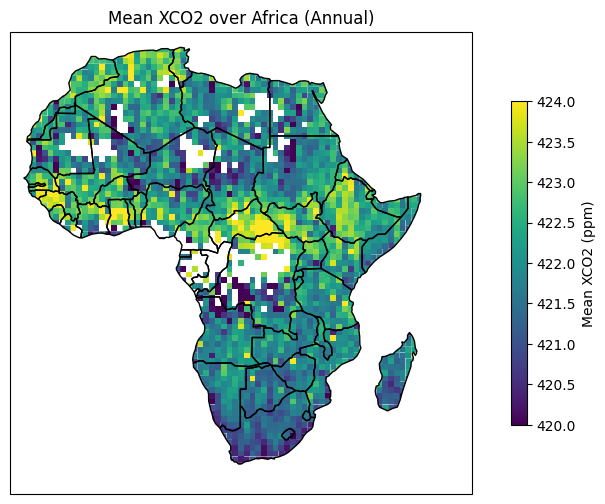

In [11]:
# 3. Annual Plot
gdf_poly = create_geodataframe_polygons(df_africa)
gdf_annual = clip_to_africa(gdf_poly, africa_shape)
plot_annual_mean_map(gdf_annual, africa_shape)

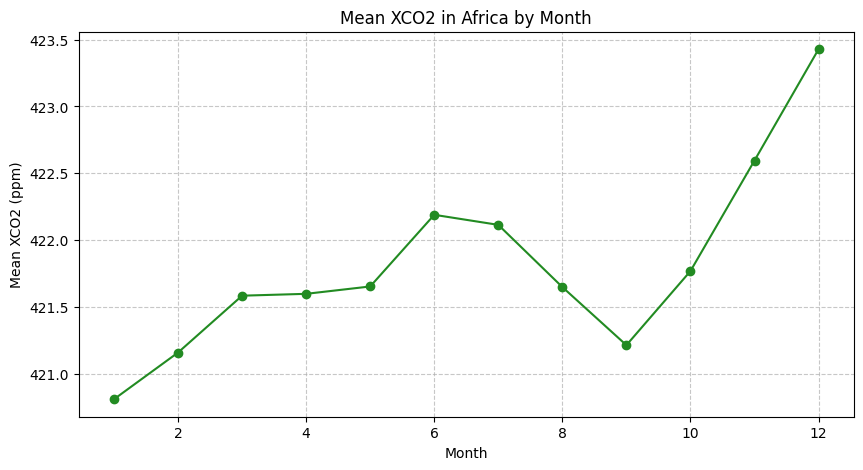

In [12]:
# 4. Monthly timeseries
plot_monthly_timeseries(df_africa)

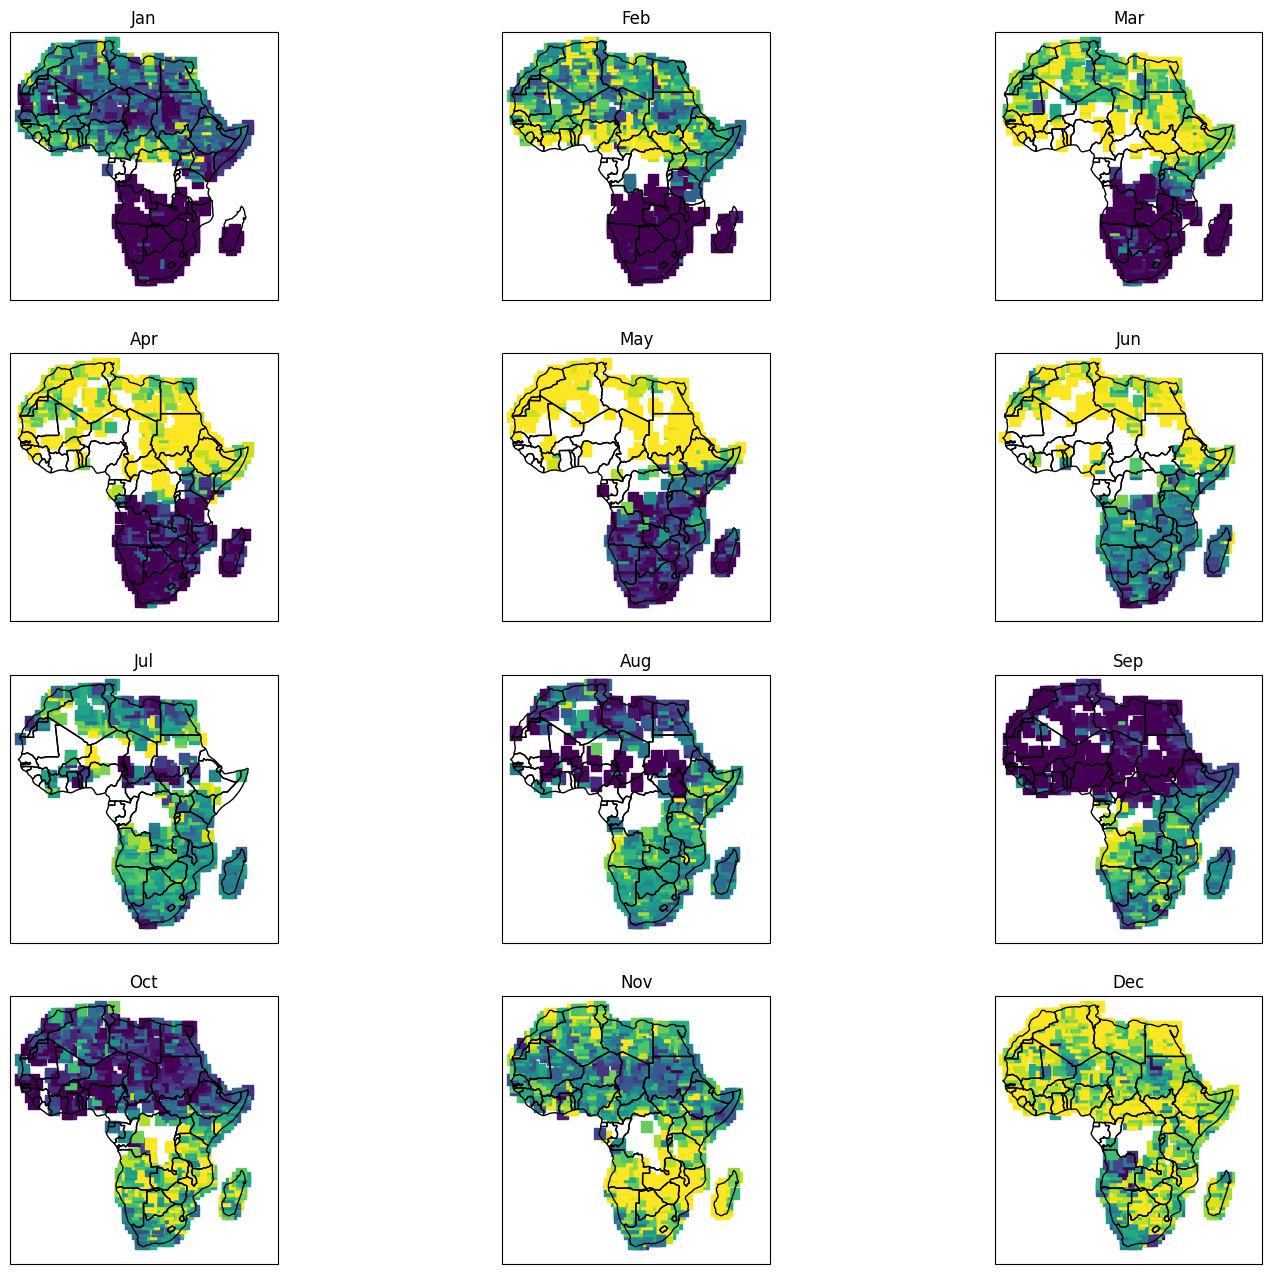

In [13]:
# --- 5. MONTHLY GRID MAPS ---
gdf_points = create_geodataframe_from_grid(df_africa)
gdf_final_points = clip_to_africa(gdf_points, africa_shape)
plot_monthly_grid(gdf_final_points, africa_shape)

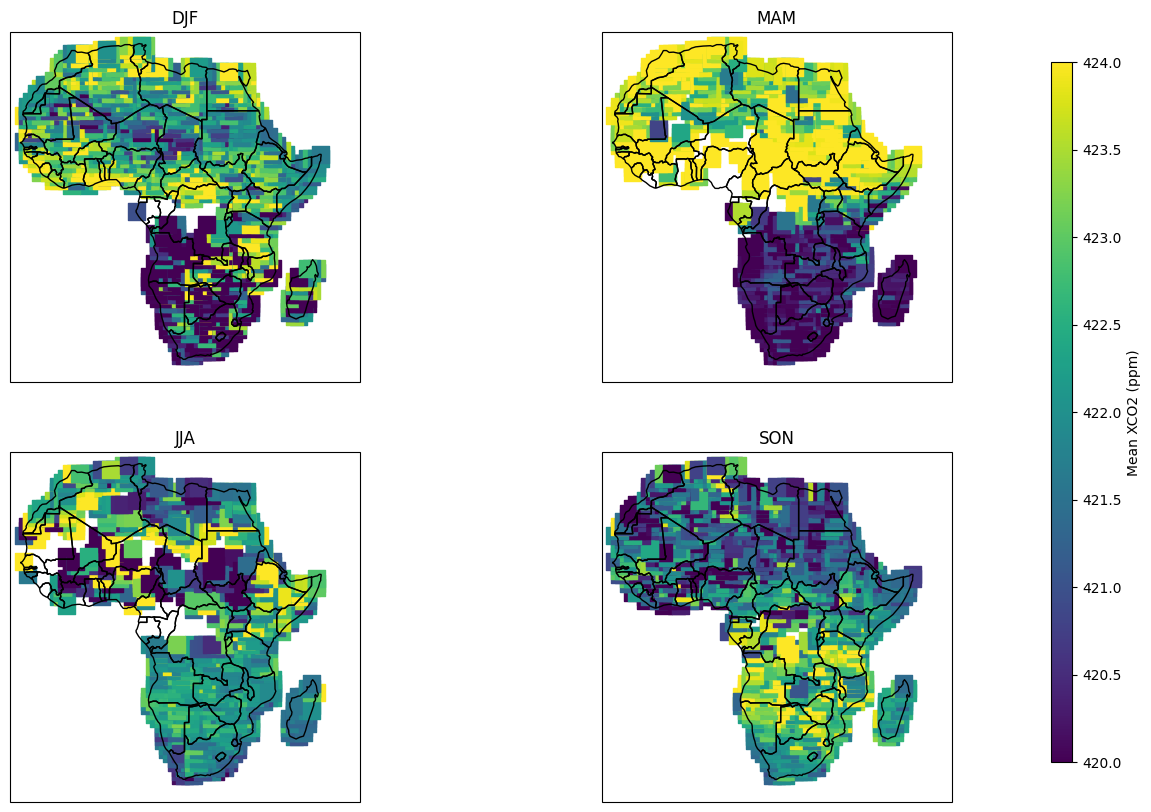

In [14]:
# --- 6. SEASONAL MAPS ---
plot_seasonal_maps(df_africa, africa_shape)

In [18]:
from spatial_analysis import extract_land_cover

# 1. Extract the values (This might take a minute)
df_africa = extract_land_cover(df_africa, "data_raster/land_cover_africa.tif")

# 2. Define the MODIS classes (Simplified for Africa)
modis_dict = {
    1: 'Forest', 2: 'Forest', 3: 'Forest', 4: 'Forest', 5: 'Forest',
    6: 'Shrubland', 7: 'Shrubland', 8: 'Savanna', 9: 'Savanna',
    10: 'Grassland', 12: 'Cropland', 13: 'Urban', 16: 'Barren/Desert', 17: 'Water'
}
df_africa['land_cover_name'] = df_africa['land_cover_code'].map(modis_dict)

# 3. Filter out the Water
# We only want to analyze CO2 over Land
df_land = df_africa[df_africa['land_cover_name'] != 'Water'].dropna(subset=['land_cover_name'])

# 4. Check how many land points you have left
print(f"Points on Land: {len(df_land)}")
print(f"Land Cover types found: {df_land['land_cover_name'].unique()}")

# 5. Analyze again
if not df_land.empty:
    lc_comparison = df_land.groupby('land_cover_name')['xco2'].mean().sort_values()
    print(lc_comparison)
else:
    print("Error: All your current points are in the Ocean. Check your Africa clipping!")

Points on Land: 0
Land Cover types found: <StringArray>
[]
Length: 0, dtype: str
Error: All your current points are in the Ocean. Check your Africa clipping!


In [17]:
print("Unique codes found in TIF:", df_africa['land_cover_code'].unique())
print("Number of rows with valid names:", df_africa['land_cover_name'].notna().sum())
print("First 5 rows of the dataframe:")
print(df_africa[['latitude', 'longitude', 'land_cover_code', 'land_cover_name']].head())

Unique codes found in TIF: [17]
Number of rows with valid names: 0
First 5 rows of the dataframe:
        latitude  longitude  land_cover_code land_cover_name
32033 -23.010427  59.990345               17             NaN
32034 -23.019815  59.984158               17             NaN
32035 -23.038507  59.971516               17             NaN
32037 -22.944570  59.999844               17             NaN
32039 -22.935400  59.989666               17             NaN


ValueError: List of boxplot statistics and `positions` values must have same the length

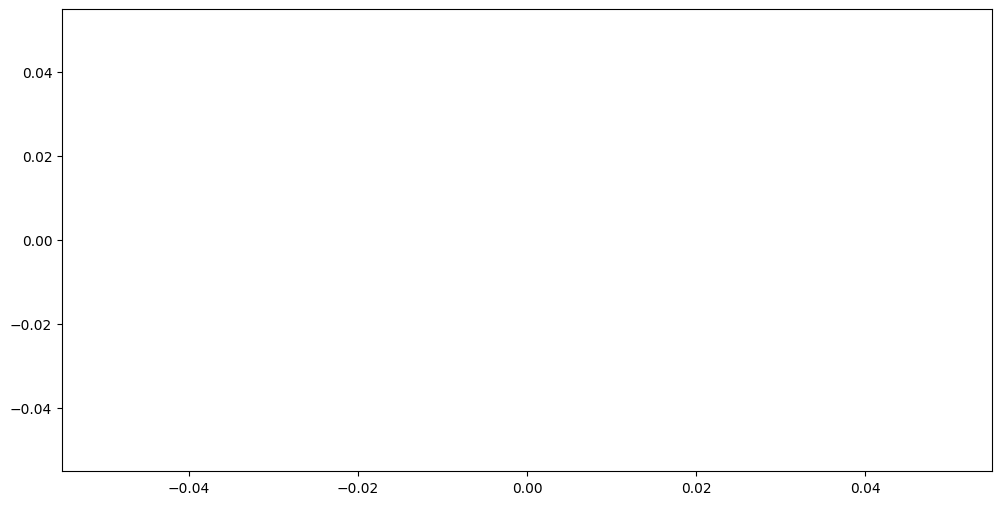

In [16]:
plot_co2_by_land_cover(df_africa)

In [19]:
# This counts how many points fall into each category
print(df_africa['land_cover_code'].value_counts())

land_cover_code
17    5194776
Name: count, dtype: int64
